---
layout: post
title: "Bayesian Decision-Making for Campaign Optimization Under Uncertainty"
date: 2026-04-12 12:00:00 -0500
---
## Uncertainty-aware personalization with practical decisioning

### Abstract
This post applies Bayesian modeling to real campaign data to understand how uncertainty affects targeting decisions. While traditional approaches rely on point estimates, Bayesian methods provide a distribution over outcomes, enabling more reliable decisions in sparse and noisy customer segments.

---

This post explores how Bayesian models can be used to move from prediction to decisioning in real campaign settings.

The focus is not just on estimating treatment effects, but on how uncertainty should influence which customer segments are actually targeted. In practice, segments with the highest estimated uplift are often the least reliable, and ignoring uncertainty can lead to suboptimal decisions.

We focus on:

- estimating treatment effects under noisy and sparse data conditions  
- understanding how uncertainty varies across customer segments  
- comparing point-estimate vs distribution-aware decision strategies  
- translating model outputs into actionable targeting decisions  

---

## Business question

> What is the effect of sending an email on conversion, and how should we target when some customer segments are sparse and noisy?

---

We use the public Hillstrom (MineThatData) email campaign dataset to evaluate how Bayesian approaches behave in a realistic marketing setting.

---

## Background and references

This analysis is informed by Bayesian modeling approaches in applied causal inference literature, including:

- Martin, O. *Bayesian Modeling and Computation in Python*

The focus here is on applying these ideas to real data and understanding their implications for decision-making under uncertainty.


In [1]:
#!pip install arviz
#!pip install pymc
#!pip install --upgrade arviz pymc pytensor
#!conda install -c conda-forge gxx
#!pip install pymc==5.10.0 arviz==0.16.1

In [2]:
#!conda activate base

In [3]:
#!conda install -c conda-forge m2w64-toolchain --solver=libmamba -v

In [4]:
import pytensor
#print(pytensor.config.cxx)

"C:\Users\revan\minicondanew\Library\mingw-w64\bin\g++.EXE"


In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the data

The notebook is written around the Hillstrom email campaign dataset.

If the public URL does not work in your environment, place the CSV next to the notebook as `hillstrom.csv`.

To keep the first blog focused, I collapse the two campaign variants into a single binary treatment:

- `treatment = 1` if the customer received any email
- `treatment = 0` if the customer received no email


In [6]:
DATA_URL = "http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"
LOCAL_PATH = "hillstrom.csv"

try:
    df = pd.read_csv(DATA_URL)
    print("Loaded from URL.")
except Exception as e:
    print("URL load failed:", e)
    df = pd.read_csv(LOCAL_PATH)
    print("Loaded from local file.")

df.columns = [c.strip().lower() for c in df.columns]
print(df.shape)
df.head()


Loaded from URL.
(64000, 12)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


Loaded from URL.
    (64000, 12)
    


## 2. Define treatment, outcome, and pre-treatment features

I use **conversion** as the main outcome because:
- Bayesian logistic regression is easy to explain
- posterior probabilities are intuitive
- decision thresholds are easier to justify

I restrict predictors to **pre-treatment** variables only.
That is basic causal discipline and keeps the model interpretable.


In [7]:
work = df.copy()

work["treatment"] = (work["segment"] != "No E-Mail").astype(int)
work["y"] = work["conversion"].astype(int)

work["history_segment"] = work["history_segment"].astype(str).str.strip()
work["zip_code"] = work["zip_code"].astype(str).str.strip()
work["channel"] = work["channel"].astype(str).str.strip()

feature_cols = [
    "recency", "history", "mens", "womens", "newbie",
    "zip_code", "channel", "history_segment"
]

work = work[feature_cols + ["treatment", "y"]].copy()
work.head()


,recency,history,mens,womens,newbie,zip_code,channel,history_segment,treatment,y
0,10,142.44,1,0,0,Surburban,Phone,2) $100 - $200,1,0
1,6,329.08,1,1,1,Rural,Web,3) $200 - $350,0,0
2,7,180.65,0,1,1,Surburban,Web,2) $100 - $200,1,0
3,9,675.83,1,0,1,Rural,Web,5) $500 - $750,1,0
4,2,45.34,1,0,0,Urban,Web,1) $0 - $100,1,0


## 3. Quick descriptive readout

This is not the final causal answer.
It is just a reality check before modeling.


In [8]:
raw_summary = work.groupby("treatment")["y"].agg(["mean", "sum", "count"])
raw_summary["conversion_rate_pct"] = 100 * raw_summary["mean"]
raw_summary


,mean,sum,count,conversion_rate_pct
treatment,,,,
0,0.005726,122,21306,0.572609
1,0.010681,456,42694,1.068066


**Interpretation**

This tells me whether treated and untreated groups move in the direction I would expect.

But raw rates are not enough for a serious decision system:
- they do not make uncertainty explicit
- they do not stabilize small segments
- they are weak support for action when slices are noisy


## 4. Classical baseline

I include a standard logistic model as a benchmark.

The point is not to say classical models are bad.
The point is to show what Bayesian modeling adds.


In [9]:
numeric_cols = ["recency", "history", "mens", "womens", "newbie", "treatment"]
categorical_cols = ["zip_code", "channel", "history_segment"]

X = work[numeric_cols + categorical_cols]
y = work["y"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore")),
        ]), categorical_cols),
    ]
)

baseline = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

baseline.fit(X, y)
baseline_proba = baseline.predict_proba(X)[:, 1]

print("Baseline log loss:", round(log_loss(y, baseline_proba), 5))
print("Baseline AUC:", round(roc_auc_score(y, baseline_proba), 5))


Baseline log loss: 0.05027
Baseline AUC: 0.64399


Baseline log loss: 0.05027
    Baseline AUC: 0.64399
    

**Interpretation**

The baseline is useful, but it still leaves open the business questions I care about:

- How uncertain is the campaign effect?
- Which segments are promising but too noisy to trust?
- What targeting rule would I actually deploy?

That is the gap Bayesian modeling helps fill.


## 5. Build a compact Bayesian modeling table

For the blog, I use a compact but realistic specification.
The idea is to keep the notebook:
- practical
- interpretable
- fast enough to run without turning the blog into an engineering exercise


In [10]:
bayes_df = work[["recency", "history", "mens", "womens", "newbie", "history_segment", "treatment", "y"]].copy()

bayes_df["group"] = bayes_df["history_segment"].astype("category")
bayes_df["group_idx"] = bayes_df["group"].cat.codes
group_names = bayes_df["group"].cat.categories.tolist()

for col in ["recency", "history"]:
    bayes_df[f"{col}_z"] = (bayes_df[col] - bayes_df[col].mean()) / bayes_df[col].std()

MAX_N = 15000
if len(bayes_df) > MAX_N:
    bayes_df = bayes_df.sample(MAX_N, random_state=RANDOM_STATE).reset_index(drop=True)

print(bayes_df.shape)
bayes_df.head()


(15000, 12)


,recency,history,mens,womens,newbie,history_segment,treatment,y,group,group_idx,recency_z,history_z
0,9,64.85,1,0,1,1) $0 - $100,1,0,1) $0 - $100,0,0.922646,-0.691898
1,1,144.12,0,1,0,2) $100 - $200,1,0,2) $100 - $200,1,-1.358121,-0.382441
2,1,734.25,0,1,1,5) $500 - $750,1,0,5) $500 - $750,4,-1.358121,1.921327
3,4,1321.26,1,0,1,"7) $1,000 +",1,0,"7) $1,000 +",6,-0.502833,4.212915
4,2,261.23,1,1,1,3) $200 - $350,1,0,3) $200 - $350,2,-1.073025,0.074736


(15000, 12)
    


## 6. Prior predictive thinking

Before fitting the model, I ask:

> If my priors were true, what sort of conversion rates would they imply?

This is practical Bayesian modeling.
Priors are assumptions, so they should generate plausible business outcomes.


Sampling: [alpha, beta_history, beta_mens, beta_newbie, beta_recency, beta_t, beta_womens]


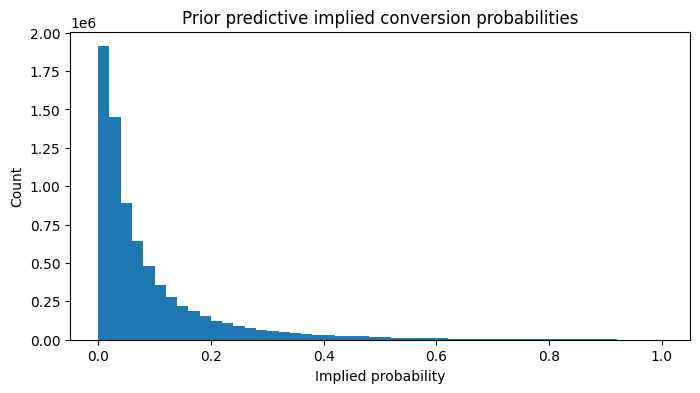

In [11]:
with pm.Model() as prior_model:
    alpha = pm.Normal("alpha", mu=-3.0, sigma=1.0)
    beta_t = pm.Normal("beta_t", mu=0.0, sigma=0.5)
    beta_recency = pm.Normal("beta_recency", mu=0.0, sigma=0.5)
    beta_history = pm.Normal("beta_history", mu=0.0, sigma=0.5)
    beta_mens = pm.Normal("beta_mens", mu=0.0, sigma=0.5)
    beta_womens = pm.Normal("beta_womens", mu=0.0, sigma=0.5)
    beta_newbie = pm.Normal("beta_newbie", mu=0.0, sigma=0.5)

    logit_p = (
        alpha
        + beta_t * bayes_df["treatment"].values
        + beta_recency * bayes_df["recency_z"].values
        + beta_history * bayes_df["history_z"].values
        + beta_mens * bayes_df["mens"].values
        + beta_womens * bayes_df["womens"].values
        + beta_newbie * bayes_df["newbie"].values
    )

    p = pm.Deterministic("p", pm.math.sigmoid(logit_p))
    prior_pred = pm.sample_prior_predictive(samples=500, random_seed=RANDOM_STATE)

prior_p = prior_pred.prior["p"].values.reshape(-1)

plt.figure(figsize=(8, 4))
plt.hist(prior_p, bins=50)
plt.title("Prior predictive implied conversion probabilities")
plt.xlabel("Implied probability")
plt.ylabel("Count")
plt.show()


Sampling: [alpha, beta_history, beta_mens, beta_newbie, beta_recency, beta_t, beta_womens]
    


    

    


**Interpretation**

What I want from this check:
- mostly low conversion probabilities
- enough flexibility for treatment and features to matter
- no prior-driven nonsense like huge probabilities for routine customers

This is one of the easiest ways to check if the prior-related assumptions are acceptable.


## 7. Bayesian logistic regression: overall campaign effect

Now I fit a pooled Bayesian logistic model.

This gives me:
- a posterior distribution over the treatment effect
- a natural way to ask probability-style questions
- a cleaner bridge from model output to action


In [12]:
coords = {"obs_id": np.arange(len(bayes_df))}

with pm.Model(coords=coords) as pooled_model:
    treatment = pm.Data("treatment", bayes_df["treatment"].values, dims="obs_id")
    recency_z = pm.Data("recency_z", bayes_df["recency_z"].values, dims="obs_id")
    history_z = pm.Data("history_z", bayes_df["history_z"].values, dims="obs_id")
    mens = pm.Data("mens", bayes_df["mens"].values, dims="obs_id")
    womens = pm.Data("womens", bayes_df["womens"].values, dims="obs_id")
    newbie = pm.Data("newbie", bayes_df["newbie"].values, dims="obs_id")
    y_obs = pm.Data("y_obs", bayes_df["y"].values, dims="obs_id")

    alpha = pm.Normal("alpha", mu=-3.0, sigma=1.0)
    beta_t = pm.Normal("beta_t", mu=0.0, sigma=0.5)
    beta_recency = pm.Normal("beta_recency", mu=0.0, sigma=0.5)
    beta_history = pm.Normal("beta_history", mu=0.0, sigma=0.5)
    beta_mens = pm.Normal("beta_mens", mu=0.0, sigma=0.5)
    beta_womens = pm.Normal("beta_womens", mu=0.0, sigma=0.5)
    beta_newbie = pm.Normal("beta_newbie", mu=0.0, sigma=0.5)

    logit_p = (
        alpha
        + beta_t * treatment
        + beta_recency * recency_z
        + beta_history * history_z
        + beta_mens * mens
        + beta_womens * womens
        + beta_newbie * newbie
    )

    p = pm.Deterministic("p", pm.math.sigmoid(logit_p), dims="obs_id")
    outcome = pm.Bernoulli("outcome", p=p, observed=y_obs, dims="obs_id")

    idata_pooled = pm.sample(
        draws=1000,
        tune=1500, #1000
        chains=4,
        target_accept=0.95, #0.90
        max_treedepth=12, #None
        random_seed=RANDOM_STATE,
        return_inferencedata=True,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_t, beta_recency, beta_history, beta_mens, beta_womens, beta_newbie]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 278 seconds.


Initializing NUTS using jitter+adapt_diag...
    Multiprocess sampling (4 chains in 4 jobs)
    NUTS: [alpha, beta_t, beta_recency, beta_history, beta_mens, beta_womens, beta_newbie]

    Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 284 seconds.


In [13]:
az.summary(
    idata_pooled,
    var_names=["alpha", "beta_t", "beta_recency", "beta_history", "beta_mens", "beta_womens", "beta_newbie"],
    round_to=3,
)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-5.264,0.276,-5.796,-4.766,0.007,0.004,1459.918,2271.160,1.004
beta_t,0.444,0.177,0.111,0.765,0.003,0.003,3096.992,2597.386,1.002
beta_recency,-0.162,0.086,-0.337,-0.006,0.001,0.001,3491.311,2748.742,1.001
beta_history,0.177,0.074,0.041,0.318,0.001,0.001,2695.236,2395.130,1.001
beta_mens,0.476,0.210,0.093,0.876,0.005,0.003,1799.914,2728.155,1.002
beta_womens,0.396,0.213,0.008,0.811,0.005,0.003,1970.892,2451.781,1.003
beta_newbie,-0.424,0.163,-0.763,-0.136,0.003,0.003,3121.234,2414.047,1.001


In [14]:
beta_t_samples = idata_pooled.posterior["beta_t"].values.reshape(-1)
prob_positive = (beta_t_samples > 0).mean()
print(f"Posterior P(email effect > 0 on log-odds scale): {prob_positive:.3f}")


Posterior P(email effect > 0 on log-odds scale): 0.996


Posterior P(email effect > 0 on log-odds scale): 0.996
    

**Interpretation**

This is where the Bayesian model becomes genuinely useful for campaign decisioning.

A classical workflow might stop at a coefficient and maybe an interval.

Here I can ask:
> What is the probability that the campaign effect is actually positive?

That is much closer to how targeting decisions are made in practice.


## 8. Posterior versus posterior predictive

This distinction matters.

- **Posterior** = uncertainty about parameters
- **Posterior predictive** = uncertainty about future outcomes

In practice, the second object is what feeds prediction and action.


In [15]:
with pooled_model:
    post_pred_pooled = pm.sample_posterior_predictive(
        idata_pooled,
        var_names=["outcome", "p"],
        random_seed=RANDOM_STATE,
    )

idata_pooled.extend(post_pred_pooled)


Sampling: [outcome]


Output()

Sampling: [outcome]


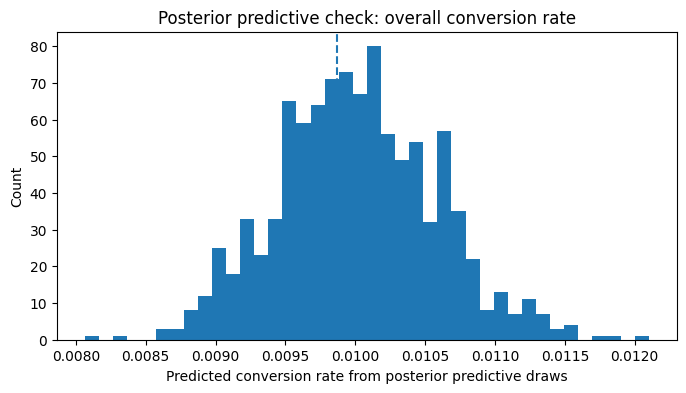

Observed conversion rate: 0.00987


In [16]:
pp_y = idata_pooled.posterior_predictive["outcome"].values
pp_rate = pp_y.mean(axis=(0, 2))
observed_rate = bayes_df["y"].mean()

plt.figure(figsize=(8, 4))
plt.hist(pp_rate, bins=40)
plt.axvline(observed_rate, linestyle="--")
plt.title("Posterior predictive check: overall conversion rate")
plt.xlabel("Predicted conversion rate from posterior predictive draws")
plt.ylabel("Count")
plt.show()

print("Observed conversion rate:", round(observed_rate, 5))


Observed conversion rate: 0.00987
    

**Interpretation**

This is one of the most practical validation checks in the notebook.

I am asking:
> Can the fitted model regenerate data with broad characteristics similar to what I actually observed?

If not, I should not trust its decision recommendations. Since observed coversion rate lies comfortably in the range shown in the histogram, this result passes the check.


## 9. Hierarchical modeling for personalization

A single global treatment effect is useful, but personalization systems usually need more.

They ask:
- which groups respond more?
- which groups are too noisy to trust?
- where should we target more aggressively?

A naive slice-by-slice estimate can be unstable.
A hierarchical model improves this through **partial pooling** and **shrinkage**.


For interpretability, I model **treatment-effect heterogeneity only across history (prior-spend) segments** while controlling for other customer attributes through shared fixed effects. This allows the Bayesian hierarchy to capture meaningful business segmentation without exploding the number of sparse subgroup combinations.


In [17]:
naive_seg = (
    bayes_df.groupby(["group", "treatment"])["y"]
    .agg(["mean", "count", "sum"])
    .reset_index()
)
#raw lift is the difference in mean conversion rates of treatment/control customers  within each segment 
pivot_rate = naive_seg.pivot(index="group", columns="treatment", values="mean")
pivot_n = naive_seg.pivot(index="group", columns="treatment", values="count")
naive_lift = (pivot_rate[1] - pivot_rate[0]).rename("raw_lift")
naive_lift = pd.concat([naive_lift, pivot_n.add_prefix("n_treat_")], axis=1)
naive_lift.sort_values("raw_lift", ascending=False)


,raw_lift,n_treat_0,n_treat_1
group,,,
4) $350 - $500,0.011695,523,988
5) $500 - $750,0.009376,395,766
3) $200 - $350,0.007777,942,1913
"6) $750 - $1,000",0.007264,160,296
1) $0 - $100,0.002492,1824,3638
2) $100 - $200,0.002194,1074,2185
"7) $1,000 +",-0.003850,87,209


In [18]:
coords_h = {
    "obs_id": np.arange(len(bayes_df)),
    "group": group_names,
}

with pm.Model(coords=coords_h) as hierarchical_model:
    treatment = pm.Data("treatment", bayes_df["treatment"].values, dims="obs_id")
    recency_z = pm.Data("recency_z", bayes_df["recency_z"].values, dims="obs_id")
    history_z = pm.Data("history_z", bayes_df["history_z"].values, dims="obs_id")
    mens = pm.Data("mens", bayes_df["mens"].values, dims="obs_id")
    womens = pm.Data("womens", bayes_df["womens"].values, dims="obs_id")
    newbie = pm.Data("newbie", bayes_df["newbie"].values, dims="obs_id")
    group_idx = pm.Data("group_idx", bayes_df["group_idx"].values, dims="obs_id")
    y_obs = pm.Data("y_obs", bayes_df["y"].values, dims="obs_id")

    alpha = pm.Normal("alpha", mu=-3.0, sigma=1.0) #+> baseline probability is low, roughly in single digit % sigma(-3)~0.047
    beta_recency = pm.Normal("beta_recency", mu=0.0, sigma=0.5)
    beta_history = pm.Normal("beta_history", mu=0.0, sigma=0.5)
    beta_mens = pm.Normal("beta_mens", mu=0.0, sigma=0.5)
    beta_womens = pm.Normal("beta_womens", mu=0.0, sigma=0.5)
    beta_newbie = pm.Normal("beta_newbie", mu=0.0, sigma=0.5)

   # mu_t = pm.Normal("mu_t", mu=0.0, sigma=0.5)
   # sigma_t = pm.HalfNormal("sigma_t", sigma=0.5)
   # beta_t_group = pm.Normal("beta_t_group", mu=mu_t, sigma=sigma_t, dims="group")
   #I use a non-centered hierarchical parameterization to improve Bayesian sampler stability.
    #This reformulation preserves the same statistical model while reducing divergences and improving convergence in sparse-segment settings.

    mu_t = pm.Normal("mu_t", mu=0.0, sigma=0.5)
    sigma_t = pm.HalfNormal("sigma_t", sigma=0.5)
    z_t = pm.Normal("z_t", mu=0.0, sigma=1.0, dims="group")
    beta_t_group = pm.Deterministic("beta_t_group", mu_t + z_t * sigma_t, dims="group")

    logit_p = (
        alpha
        + beta_t_group[group_idx] * treatment
        + beta_recency * recency_z
        + beta_history * history_z
        + beta_mens * mens
        + beta_womens * womens
        + beta_newbie * newbie
    )

    p = pm.Deterministic("p", pm.math.sigmoid(logit_p), dims="obs_id")
    outcome = pm.Bernoulli("outcome", p=p, observed=y_obs, dims="obs_id")

    idata_h = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.92,
        random_seed=RANDOM_STATE,
        return_inferencedata=True,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_recency, beta_history, beta_mens, beta_womens, beta_newbie, mu_t, sigma_t, z_t]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 298 seconds.


Initializing NUTS using jitter+adapt_diag...
    Multiprocess sampling (4 chains in 4 jobs)
    NUTS: [alpha, beta_recency, beta_history, beta_mens, beta_womens, beta_newbie, mu_t, sigma_t, z_t]

    Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 299 seconds.
    

To stabilize sampling in the hierarchical treatment-effect model, I use a non-centered parameterization for segment-level treatment effects.

Instead of sampling each segment treatment effect directly from:

β_t_group ~ Normal(μ_t, σ_t)

I reparameterize as:

z_t ~ Normal(0, 1)

β_t_group = μ_t + z_t × σ_t

This mathematically represents the same hierarchical model, but often samples much more efficiently in Bayesian hierarchical settings.

Why this matters:
- Direct centered parameterization can create strong posterior correlations between group effects and hierarchy parameters.
- That often leads to divergences, poor effective sample size, and slow NUTS convergence.
- Non-centered parameterization reduces this geometry problem and improves sampler stability.

This is especially useful when:
- Some groups are sparse
- Hierarchical variance is small
- Partial pooling is strong


In [19]:
az.summary(idata_h, var_names=["mu_t", "sigma_t", "beta_t_group"], round_to=3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_t,0.427,0.194,0.084,0.812,0.003,0.003,3285.879,2711.547,1.003
sigma_t,0.182,0.142,0.000,0.437,0.003,0.002,1682.274,1786.548,1.000
beta_t_group[1) $0 - $100],0.439,0.203,0.057,0.825,0.003,0.003,4646.861,3169.858,1.001
beta_t_group[2) $100 - $200],0.353,0.227,-0.112,0.745,0.004,0.003,3561.391,2925.678,1.002
beta_t_group[3) $200 - $350],0.419,0.212,0.002,0.802,0.003,0.003,4833.690,3483.099,1.000
beta_t_group[4) $350 - $500],0.560,0.238,0.123,1.003,0.004,0.003,3055.097,3139.759,1.001
beta_t_group[5) $500 - $750],0.500,0.240,0.052,0.953,0.004,0.003,3675.060,3178.447,1.001
"beta_t_group[6) $750 - $1,000]",0.400,0.266,-0.107,0.895,0.004,0.004,3962.511,3423.523,1.002
"beta_t_group[7) $1,000 +]",0.397,0.277,-0.148,0.902,0.004,0.005,3771.996,3328.389,1.001


R-hat ≈ 1.000–1.003
Excellent
Effective Sample Size
ESS mostly 3000–4800

posterior samples are now reliable enough to interpret as

R-hat < 1.01
ESS > 400 (100 × number_of_chains)
Divergences = 0


In [20]:
beta_group = idata_h.posterior["beta_t_group"].stack(sample=("chain", "draw")).values

hier = pd.DataFrame({
    "group": group_names,
    "post_mean_logodds_effect": beta_group.mean(axis=1),
    "post_prob_positive": (beta_group > 0).mean(axis=1),
    "post_p10": np.quantile(beta_group, 0.10, axis=1),
    "post_p90": np.quantile(beta_group, 0.90, axis=1),
})

comparison = naive_lift.reset_index().merge(hier, on="group", how="left")
comparison.sort_values("post_prob_positive", ascending=False)


,group,raw_lift,n_treat_0,n_treat_1,post_mean_logodds_effect,post_prob_positive,post_p10,post_p90
3,4) $350 - $500,0.011695,523,988,0.560170,0.99675,0.265967,0.884051
4,5) $500 - $750,0.009376,395,766,0.500078,0.98700,0.204615,0.808252
0,1) $0 - $100,0.002492,1824,3638,0.439379,0.98375,0.184999,0.697553
2,3) $200 - $350,0.007777,942,1913,0.418892,0.97775,0.149250,0.681799
5,"6) $750 - $1,000",0.007264,160,296,0.399655,0.93500,0.070966,0.726050
6,"7) $1,000 +",-0.003850,87,209,0.397161,0.92925,0.059925,0.724186
1,2) $100 - $200,0.002194,1074,2185,0.353053,0.92825,0.053629,0.628934


-  The hierarchical Bayesian model identified statistically credible heterogeneity in treatment response across customer value segments.
Segment-level treatment effects were partially pooled toward the population mean, reducing noise relative to naïve segment estimates while preserving meaningful differences where supported by data.

**Interpretation**

This is where the approach becomes especially useful for personalization.

The raw segment effects are easy to compute but often too noisy to trust.
The hierarchical model provides:
- stable segment-level estimates
- a direct probability that each segment benefits
- much less temptation to chase random extremes from thin data
  
The posterior probability of positive treatment effect exceeds 92% across all customer history segments, indicating broad evidence that email campaigns improve conversion. However, the magnitude of expected benefit varies by segment, suggesting that while blanket suppression is not warranted, prioritization by expected incremental value remains appropriate.

## 10. Turning model output into decisions

A model is only useful if it can support action.

Below is a simple policy-style interpretation:
- high posterior probability of benefit -> target confidently
- moderate posterior probability -> promising, but monitor or test more
- weak posterior probability -> de-prioritize for now


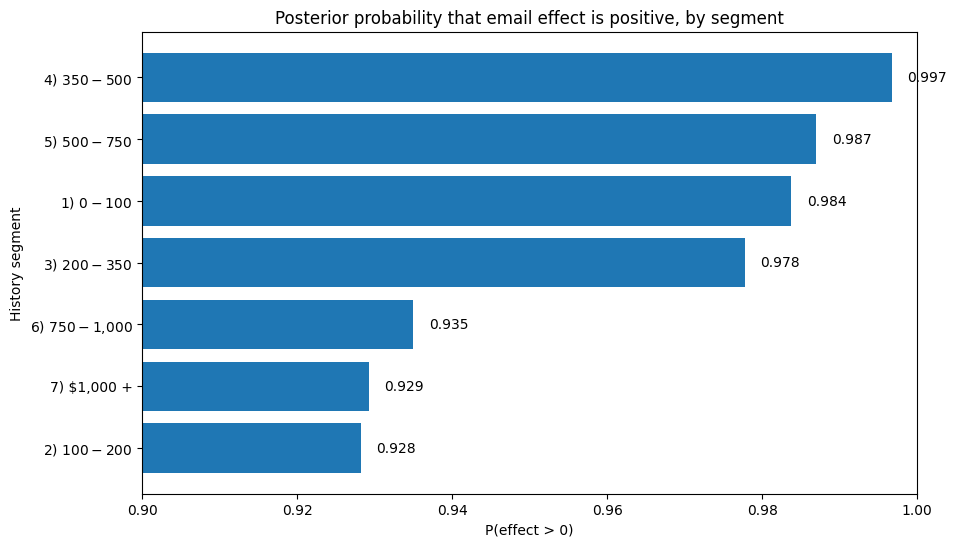

In [21]:
plot_df = comparison.sort_values("post_prob_positive", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["group"].astype(str), plot_df["post_prob_positive"])
plt.axvline(0.8, linestyle="--")
plt.title("Posterior probability that email effect is positive, by segment")
plt.xlim(0.90, 1.0)
plt.xlabel("P(effect > 0)")
plt.ylabel("History segment")
for i, v in enumerate(plot_df["post_prob_positive"]):
    plt.text(v + 0.002, i, f"{v:.3f}", va="center")
plt.show()


In [22]:
decision_df = comparison[["group", "post_prob_positive", "post_mean_logodds_effect", "post_p10", "post_p90"]].copy()

decision_df["recommended_action"] = np.select(
    [
        decision_df["post_prob_positive"] >= 0.90,
        decision_df["post_prob_positive"].between(0.70, 0.90, inclusive="left"),
    ],
    [
        "Target confidently",
        "Promising but monitor / test more",
    ],
    default="Weak evidence: deprioritize for now",
)

decision_df.sort_values("post_prob_positive", ascending=False)


,group,post_prob_positive,post_mean_logodds_effect,post_p10,post_p90,recommended_action
3,4) $350 - $500,0.99675,0.560170,0.265967,0.884051,Target confidently
4,5) $500 - $750,0.98700,0.500078,0.204615,0.808252,Target confidently
0,1) $0 - $100,0.98375,0.439379,0.184999,0.697553,Target confidently
2,3) $200 - $350,0.97775,0.418892,0.149250,0.681799,Target confidently
5,"6) $750 - $1,000",0.93500,0.399655,0.070966,0.726050,Target confidently
6,"7) $1,000 +",0.92925,0.397161,0.059925,0.724186,Target confidently
1,2) $100 - $200,0.92825,0.353053,0.053629,0.628934,Target confidently


**Interpretation**
A naïve segment-level uplift table would have suggested suppressing email to the highest-value customers (1000$+ group) because observed raw lift was negative in that sparse segment as shown in a previous table.
However, the hierarchical Bayesian model identified that the apparent negative lift was likely noise caused by limited sample size. After partial pooling, posterior probability of positive treatment effect for that segment remained above 92%.
This demonstrates how Bayesian hierarchical models prevent overreaction to noisy segment-level estimates in personalization systems.
This is the practical payoff.

The model is not just producing parameters.
It is supporting a targeting rule that explicitly accounts for uncertainty.

That is one of the biggest reasons Bayesian models are attractive in campaign analytics and personalization systems.


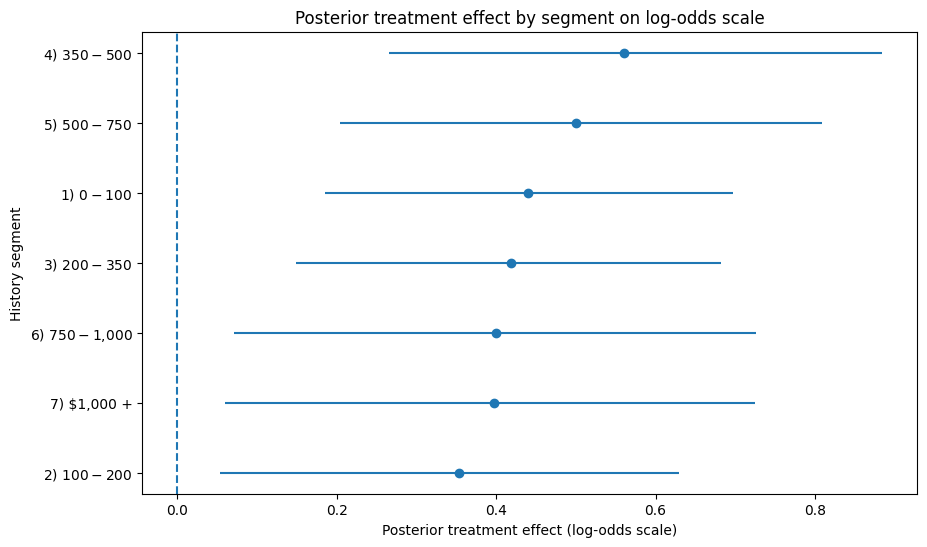

In [23]:
effect_df = comparison.sort_values("post_mean_logodds_effect", ascending=True).copy()

plt.figure(figsize=(10, 6))
plt.errorbar(
    x=effect_df["post_mean_logodds_effect"],
    y=effect_df["group"].astype(str),
    xerr=[
        effect_df["post_mean_logodds_effect"] - effect_df["post_p10"],
        effect_df["post_p90"] - effect_df["post_mean_logodds_effect"]
    ],
    fmt="o"
)

plt.axvline(0, linestyle="--")
plt.title("Posterior treatment effect by segment on log-odds scale")
plt.xlabel("Posterior treatment effect (log-odds scale)")
plt.ylabel("History segment")
plt.show()

These effects are shown on the log-odds scale from the Bayesian logistic model, so they are useful for relative segment ranking but not yet a direct measure of business lift.
I use two complementary views of segment-level treatment effects. The first plot shows the posterior probability that email has a positive effect for each segment, which is useful for suppression or go/no-go decisions. The second plot shows posterior mean treatment effect with uncertainty intervals, which is more useful for prioritizing segments by expected incremental impact.


In [24]:
import numpy as np
import pandas as pd

# Pull posterior draws
posterior = idata_h.posterior

alpha_s = posterior["alpha"].values.reshape(-1)
beta_recency_s = posterior["beta_recency"].values.reshape(-1)
beta_history_s = posterior["beta_history"].values.reshape(-1)
beta_mens_s = posterior["beta_mens"].values.reshape(-1)
beta_womens_s = posterior["beta_womens"].values.reshape(-1)
beta_newbie_s = posterior["beta_newbie"].values.reshape(-1)

# shape: (n_groups, n_samples)
beta_t_group_s = posterior["beta_t_group"].stack(sample=("chain", "draw")).values

# Build one row per segment using average feature values inside that segment.
segment_profiles = (
    bayes_df.groupby("group")
    .agg(
        recency_z=("recency_z", "mean"),
        history_z=("history_z", "mean"),
        mens=("mens", "mean"),
        womens=("womens", "mean"),
        newbie=("newbie", "mean"),
        n=("y", "size"),
        observed_conversion=("y", "mean"),
    )
    .reset_index()
)

rows = []

for g_idx, row in segment_profiles.iterrows():
    # Linear predictor under control
    eta_control = (
        alpha_s
        + beta_recency_s * row["recency_z"]
        + beta_history_s * row["history_z"]
        + beta_mens_s * row["mens"]
        + beta_womens_s * row["womens"]
        + beta_newbie_s * row["newbie"]
    )

    # Add treatment effect for treated scenario
    eta_treat = eta_control + beta_t_group_s[g_idx, :]

    # Convert log-odds to probabilities
    p_control = 1 / (1 + np.exp(-eta_control))
    p_treat = 1 / (1 + np.exp(-eta_treat))
    uplift = p_treat - p_control

    rows.append({
        "group": row["group"],
        "n": row["n"],
        "observed_conversion": row["observed_conversion"],
        "post_control_mean": p_control.mean(),
        "post_treat_mean": p_treat.mean(),
        "post_uplift_mean": uplift.mean(),
        "post_uplift_p10": np.quantile(uplift, 0.10),
        "post_uplift_p90": np.quantile(uplift, 0.90),
        "prob_uplift_positive": (uplift > 0).mean(),
    })

uplift_df = pd.DataFrame(rows).sort_values("post_uplift_mean", ascending=False)
uplift_df

,group,n,observed_conversion,post_control_mean,post_treat_mean,post_uplift_mean,post_uplift_p10,post_uplift_p90,prob_uplift_positive
6,"7) $1,000 +",296,0.020270,0.015221,0.022415,0.007193,0.000990,0.013722,0.92925
3,4) $350 - $500,1511,0.017207,0.009198,0.016049,0.006850,0.003115,0.011291,0.99675
4,5) $500 - $750,1161,0.013781,0.008203,0.013473,0.005271,0.002057,0.008803,0.98700
5,"6) $750 - $1,000",456,0.010965,0.010519,0.015694,0.005176,0.000820,0.009574,0.93500
2,3) $200 - $350,2855,0.009457,0.007654,0.011575,0.003922,0.001338,0.006472,0.97775
0,1) $0 - $100,5462,0.008239,0.005577,0.008583,0.003006,0.001281,0.004754,0.98375
1,2) $100 - $200,3259,0.007057,0.006177,0.008776,0.002600,0.000363,0.004645,0.92825


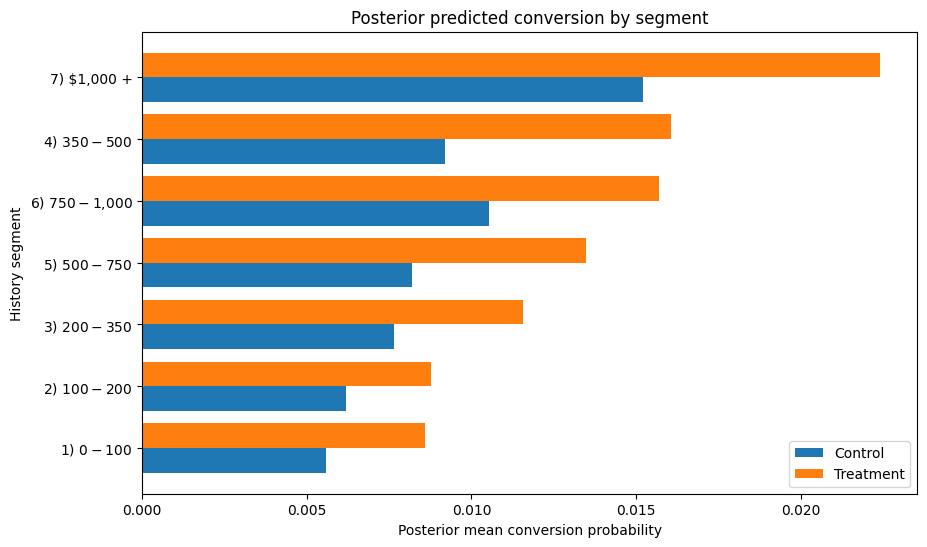

In [25]:
plot_df = uplift_df.sort_values("post_treat_mean", ascending=True)

y_pos = np.arange(len(plot_df))

plt.figure(figsize=(10, 6))
plt.barh(y_pos - 0.2, plot_df["post_control_mean"], height=0.4, label="Control")
plt.barh(y_pos + 0.2, plot_df["post_treat_mean"], height=0.4, label="Treatment")

plt.yticks(y_pos, plot_df["group"].astype(str))
plt.xlabel("Posterior mean conversion probability")
plt.ylabel("History segment")
plt.title("Posterior predicted conversion by segment")
plt.legend()
plt.show()

Rather than ranking segments purely on treatment effect coefficient size or raw observed lift, I convert posterior segment effects into expected conversion under treatment and control. This makes the output directly useful for decisioning: it tells me not only whether a segment is likely to benefit, but also how much incremental conversion I should expect if I target it.

While all segments show positive expected uplift, the model suggests prioritizing the highest-history and mid-high-history customers first, with the $1,000+ segment exhibiting the largest expected incremental conversion despite relatively sparse data. This ranking differs materially from naïve raw-lift and coefficient-based ranking, highlighting the importance of converting posterior treatment effects into expected business uplift before decisioning.


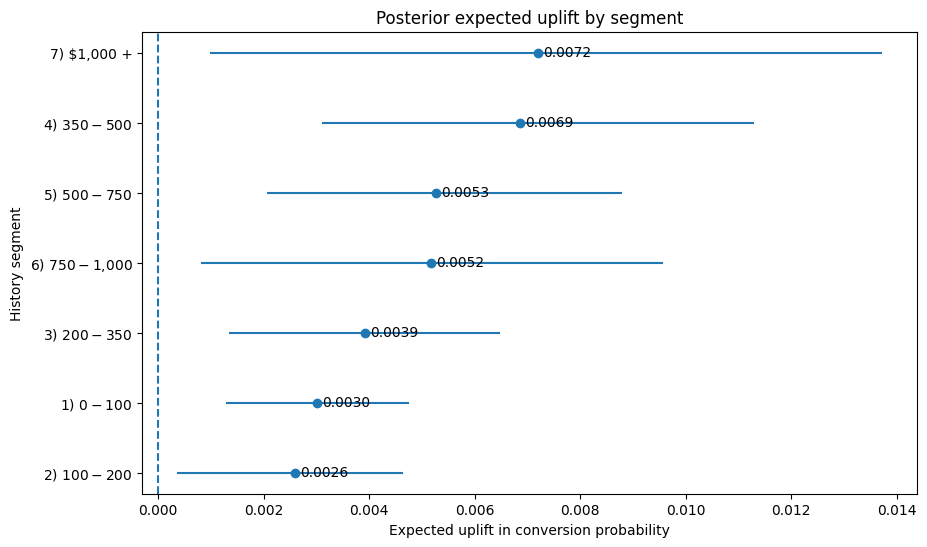

In [26]:
plot_df = uplift_df.sort_values("post_uplift_mean", ascending=True).copy()

plt.figure(figsize=(10, 6))
plt.errorbar(
x=plot_df["post_uplift_mean"],
y=plot_df["group"].astype(str),
xerr=[
plot_df["post_uplift_mean"] - plot_df["post_uplift_p10"],
plot_df["post_uplift_p90"] - plot_df["post_uplift_mean"]
],
fmt="o"
)

for i, row in plot_df.reset_index(drop=True).iterrows():
    plt.text(
    row["post_uplift_mean"] + 0.0001,
    i,
    f"{row['post_uplift_mean']:.4f}",
    va="center"
    )

plt.axvline(0, linestyle="--")
plt.title("Posterior expected uplift by segment")
plt.xlabel("Expected uplift in conversion probability")
plt.ylabel("History segment")
plt.show()

While all segments show positive expected uplift, the model suggests prioritizing the highest-history and mid-high-history customers first, with the $1,000+ segment exhibiting the largest expected incremental conversion despite relatively sparse data. This ranking differs materially from naïve raw-lift and coefficient-based ranking, highlighting the importance of converting posterior treatment effects into expected business uplift before decisioning.


This plot translates posterior treatment effects into expected incremental conversion by segment, which is more directly useful for campaign prioritization than coefficient estimates on the log-odds scale. The point estimate shows expected uplift, while the interval reflects posterior uncertainty.


## 11. Final takeaways
This post shows how Bayesian Causal modeling can be applied in a real campaign decisioning setting-not just to estimate treatment effects, but to make better targeting decisions under uncertainty.
Specifically, I:

- estimated heterogeneous email treatment effects across customer spend segments
- used hierarchical partial pooling to stabilize sparse segment estimates
- validated convergence and sampling diagnostics before trusting the posterior
- translated posterior treatment effects from log-odds into expected conversion uplift
- ranked segments using expected incremental conversion rather than naïve observed lift
- quantified uncertainty using posterior uplift intervals and probability uplift is positive


Practical Lesson:


>Bayesian uplift models are most valuable when segment-level treatment effects are noisy, sparse, or high stakes enough that uncertainty should influence targeting decisions—not just point estimates
